## dset init

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, f1_score
from torch.utils.data import DataLoader, Dataset

#no augmentations dataset class
"""
class MITBIHDataset(Dataset):

  def __init__(self, csv_file):
    df = pd.read_csv(csv_file, header=None)
    data = df.values
    self.X = data[:, :-1].astype(np.float32)
    self.y = data[:, -1].astype(np.int64)

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    x = torch.from_numpy(self.X[idx]).unsqueeze(-1)
    y = torch.tensor(self.y[idx], dtype=torch.long)
    return x, y
"""

'\nclass MITBIHDataset(Dataset):\n\n  def __init__(self, csv_file):\n    df = pd.read_csv(csv_file, header=None)\n    data = df.values\n    self.X = data[:, :-1].astype(np.float32)\n    self.y = data[:, -1].astype(np.int64)\n\n  def __len__(self):\n    return len(self.y)\n\n  def __getitem__(self, idx):\n    x = torch.from_numpy(self.X[idx]).unsqueeze(-1)\n    y = torch.tensor(self.y[idx], dtype=torch.long)\n    return x, y\n'

## dset class w/ augmentations excluding normal class

In [2]:
class MITBIHDataset(Dataset):

  def __init__(self, csv_file, is_train=True):
    df = pd.read_csv(csv_file, header=None)
    data = df.values
    self.X = data[:, :-1].astype(np.float32)
    self.y = data[:, -1].astype(np.int64) #last column in dataset contains output class 0-4 int
    self.is_train = is_train

  def __len__(self):
    return len(self.y)


  def _augment(self, x):
    if np.random.rand() < 0.5:
      noise = np.random.normal(0.0, 0.015, size=x.shape).astype(np.float32)
      x = x + noise

    if np.random.rand() < 0.5:
      scale = np.random.uniform(0.85, 1.15)
      x = x * scale

    if np.random.rand() < 0.5:
      shift = np.random.randint(-10, 11)
      if shift > 0:
        x = np.pad(x, (shift, 0), mode="constant", constant_values=0.0)[:-shift]
      elif shift < 0:
        x = np.pad(x, (0, -shift), mode="constant", constant_values=0.0)[-shift:]

    if np.random.rand() < 0.3:
      mask_len = np.random.randint(5, 16)
      start = np.random.randint(0, len(x) - mask_len)
      x[start : start + mask_len] = 0.0

    return x

  def __getitem__(self, idx):
    x_np = self.X[idx].copy()
    y_val = self.y[idx]

      #no augmnetations applied for the majority class
    if self.is_train and y_val != 0:
      x_np = self._augment(x_np)

    x = torch.from_numpy(x_np).unsqueeze(-1)
    y = torch.tensor(y_val, dtype=torch.long)
    return x, y

## model init

In [3]:
import math
import random
import numpy as np
import torch
import torch.nn as nn

#fixed seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

#model hyperparams
IN_CHANNELS = 1 #DOES NOT CHANGE
D_MODEL = 64
NHEAD = 4
NUM_LAYERS = 3
DIM_FEEDFORWARD = 128
DROPOUT = 0.25
NUM_CLASSES = 5 #DOES NOT CHANGE
MAX_LEN = 300
HEAD_HIDDEN_DIM = 64
CLS_INIT_STD = 0.02


class PositionalEncoding(nn.Module):

  def __init__(self, d_model=D_MODEL, max_len=MAX_LEN):
    super().__init__()
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
    )

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    self.register_buffer("pe", pe.unsqueeze(0))

  def forward(self, x):
    return x + self.pe[:, : x.size(1), :]


class ECGTransformerClassifier(nn.Module):

  def __init__(
      self,
      in_channels=IN_CHANNELS,
      d_model=D_MODEL,
      nhead=NHEAD,
      num_layers=NUM_LAYERS,
      dim_feedforward=DIM_FEEDFORWARD,
      dropout=DROPOUT,
      num_classes=NUM_CLASSES,
      head_hidden_dim=HEAD_HIDDEN_DIM,
      cls_init_std=CLS_INIT_STD,
      max_len=MAX_LEN,
  ):
    super().__init__()

    #conv1d on the entire signal
    self.input_projection = nn.Sequential(
        nn.Conv1d(in_channels, d_model, kernel_size=7, stride=2, padding=3), 
        nn.BatchNorm1d(d_model),
        nn.GELU(),
    )
      
    #positional encodings
    self.pos_encoder = PositionalEncoding(d_model=d_model, max_len=max_len)

    encoder_layer = nn.TransformerEncoderLayer(
        d_model=d_model,
        nhead=nhead,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        activation="gelu",
        batch_first=True,
    )

    #1d transformer 
    self.transformer_encoder = nn.TransformerEncoder(
        encoder_layer, num_layers=num_layers
    )

    #final MLP classification head 
    self.head = nn.Sequential(
        nn.LayerNorm(d_model),
        nn.Linear(d_model, head_hidden_dim),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(head_hidden_dim, num_classes),
    )

  def forward(self, x):
    x = x.transpose(1, 2)
    x = self.input_projection(x)
    x = x.transpose(1, 2)

    x = self.pos_encoder(x)
    out = self.transformer_encoder(x)

    rep = out.mean(dim=1)
    logits = self.head(rep)
    return logits

## training

In [4]:
train_csv = "/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_train.csv"
test_csv = "/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_test.csv"

train_dataset = MITBIHDataset(train_csv)
test_dataset = MITBIHDataset(test_csv)

#train_dataset = MITBIHDataset(final_train_df)
#test_dataset = MITBIHDataset(final_test_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#class weights calculated relative to instances: lower minority classes contribute more to loss function
train_labels = train_dataset.y
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

#model instantiate
model = ECGTransformerClassifier(
    in_channels=1,
    d_model=128,
    nhead=8,
    num_layers=4,
    dim_feedforward=256,
    dropout=0.1,
    num_classes=5,
)

#split across 2 gpus for faster fitting
if torch.cuda.device_count() > 1:
  model = nn.DataParallel(model)

model = model.to(device)

#weighted ce
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=20, eta_min=1e-5
)

#mixed precision
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_58/2868032191.py:60: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [5]:
epochs = 100
patience = 20 #long patience count since model showed constant improvement of loss without returning a new best macro f1
patience_counter = 0
best_macro_f1 = -1.0
best_model_path = "best_ecg_transformer.pth"

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=epochs, eta_min=1e-5
)

for epoch in range(epochs):
  model.train()
  running_loss = 0.0

  for x_batch, y_batch in train_loader:
    x_batch = x_batch.to(device, non_blocking=True)
    y_batch = y_batch.to(device, non_blocking=True)

    optimizer.zero_grad()

    with torch.cuda.amp.autocast():
      logits = model(x_batch)
      loss = criterion(logits, y_batch)

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()

    running_loss += loss.item() * x_batch.size(0)

  scheduler.step()
  train_loss = running_loss / len(train_dataset)

  model.eval()
  all_preds = []
  all_targets = []

  with torch.no_grad():
    for x_batch, y_batch in test_loader:
      x_batch = x_batch.to(device, non_blocking=True)
      with torch.cuda.amp.autocast():
        logits = model(x_batch)
      preds = torch.argmax(logits, dim=1).cpu().numpy()
      all_preds.extend(preds)
      all_targets.extend(y_batch.numpy())

#early stopping based on test set macro F1
  macro_f1 = f1_score(all_targets, all_preds, average="macro")
  print(
      f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {train_loss:.4f} | Test"
      f" Macro F1: {macro_f1:.4f}"
  )

  if macro_f1 > best_macro_f1:
    best_macro_f1 = macro_f1
    patience_counter = 0
    state_to_save = (
        model.module.state_dict()
        if isinstance(model, nn.DataParallel)
        else model.state_dict()
    )
    torch.save(state_to_save, best_model_path)
    print(f"  --> Saved new best model with Macro F1: {best_macro_f1:.4f}")
  else:
    patience_counter += 1
    print(f"  --> EarlyStopping counter: {patience_counter}/{patience}")
    if patience_counter >= patience:
      print(f"\nEarly stopping triggered after {epoch+1} epochs.")
      break

best_state = torch.load(best_model_path)
if isinstance(model, nn.DataParallel):
  model.module.load_state_dict(best_state)
else:
  model.load_state_dict(best_state)

model.eval()
final_preds = []
final_targets = []

with torch.no_grad():
  for x_batch, y_batch in test_loader:
    x_batch = x_batch.to(device, non_blocking=True)
    with torch.cuda.amp.autocast():
      logits = model(x_batch)
    preds = torch.argmax(logits, dim=1).cpu().numpy()
    final_preds.extend(preds)
    final_targets.extend(y_batch.numpy())

print(f"\nFinal Best Classification Report (Macro F1: {best_macro_f1:.4f}):")
print(
    classification_report(
        final_targets,
        final_preds,
        target_names=["Non-Ectopic", "Supravent.", "Vent.", "Fusion", "Unknown"],
    )
)

/tmp/ipykernel_58/2675464655.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_58/2675464655.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 01/100 | Train Loss: 0.8168 | Test Macro F1: 0.5616
  --> Saved new best model with Macro F1: 0.5616


/tmp/ipykernel_58/2675464655.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_58/2675464655.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 02/100 | Train Loss: 0.4758 | Test Macro F1: 0.7192
  --> Saved new best model with Macro F1: 0.7192


/tmp/ipykernel_58/2675464655.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_58/2675464655.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 99/100 | Train Loss: 0.0432 | Test Macro F1: 0.9230
  --> EarlyStopping counter: 2/20


/tmp/ipykernel_58/2675464655.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_58/2675464655.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 100/100 | Train Loss: 0.0417 | Test Macro F1: 0.9274
  --> EarlyStopping counter: 3/20


/tmp/ipykernel_58/2675464655.py:85: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Final Best Classification Report (Macro F1: 0.9313):
              precision    recall  f1-score   support

 Non-Ectopic       1.00      0.99      0.99     18118
  Supravent.       0.86      0.90      0.88       556
       Vent.       0.96      0.96      0.96      1448
      Fusion       0.75      0.90      0.82       162
     Unknown       0.98      0.99      0.99      1608

    accuracy                           0.99     21892
   macro avg       0.91      0.95      0.93     21892
weighted avg       0.99      0.99      0.99     21892



## confusion matrix full test set

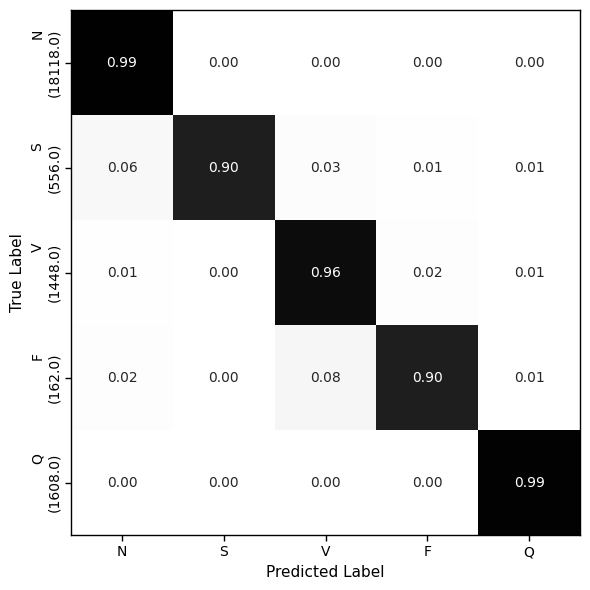

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

base_labels = ["N", "S", "V", "F", "Q"]

cm = confusion_matrix(final_targets, final_preds)
class_counts = cm.sum(axis=1)

y_labels = [f"{label}\n({float(count)})" for label, count in zip(base_labels, class_counts)]
x_labels = base_labels

cm_normalized = cm.astype("float") / class_counts[:, np.newaxis]

fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Greys",
    cbar=False,
    vmin=0.0,
    vmax=1.0,
    xticklabels=x_labels,
    yticklabels=y_labels,
    ax=ax,
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.0)

ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.tick_params(axis="both", length=4, width=1.0, colors="black")

#fig.text(0.1, -0.08, ha="left", va="top", fontsize=10)

plt.tight_layout()
plt.show()

## confusion matrix balanced test set

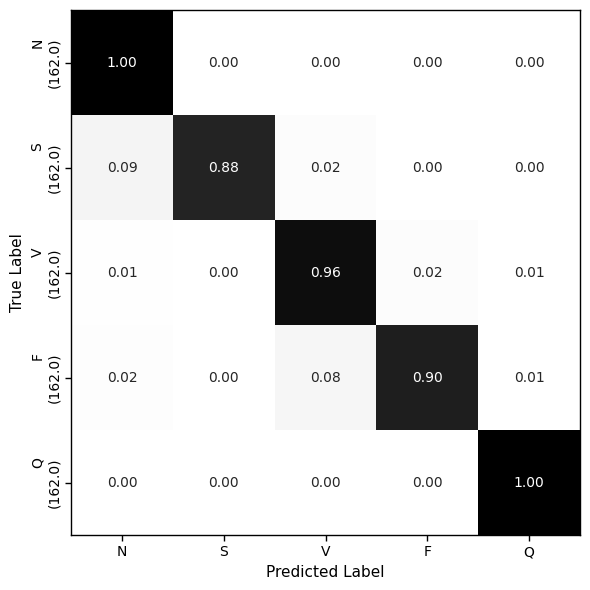

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

base_labels = ["N", "S", "V", "F", "Q"]

targets_arr = np.array(final_targets)
preds_arr = np.array(final_preds)

min_samples = 162
balanced_indices = []

rng = np.random.default_rng(seed=42)

for cls_idx in range(len(base_labels)):
    cls_indices = np.where(targets_arr == cls_idx)[0]
    sampled_indices = rng.choice(cls_indices, size=min_samples, replace=False)
    balanced_indices.extend(sampled_indices)

balanced_targets = targets_arr[balanced_indices]
balanced_preds = preds_arr[balanced_indices]

cm = confusion_matrix(balanced_targets, balanced_preds)
class_counts = cm.sum(axis=1)

y_labels = [f"{label}\n({float(count)})" for label, count in zip(base_labels, class_counts)]
x_labels = base_labels

cm_normalized = cm.astype("float") / class_counts[:, np.newaxis]

fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Greys",
    cbar=False,
    vmin=0.0,
    vmax=1.0,
    xticklabels=x_labels,
    yticklabels=y_labels,
    ax=ax,
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.0)

ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.tick_params(axis="both", length=4, width=1.0, colors="black")

#fig.text(0.1, -0.08, caption, ha="left", va="top", wrap=True, fontsize=10)

plt.tight_layout()
plt.show()